In [219]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [220]:
df = pd.read_csv("06-study_hours_grades.csv")

In [221]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [223]:
# data
# build a model
# prediction with model
# evaluation
# improvement
# save the model

In [224]:
df.describe()

,study_hours,grade
count,50.000000,50.000000
mean,4.459239,32.290305
std,2.888832,14.431931
min,0.205845,11.032281
25%,1.837670,21.062901
50%,4.360488,31.231858
75%,6.498549,41.683170
max,9.699099,60.573564


In [225]:
type(df["study_hours"].values)

numpy.ndarray

In [226]:
torch.tensor(df["study_hours"].values)

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [227]:
torch.tensor(df["study_hours"].values)

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [228]:
y = torch.tensor(df["grade"].values)
X = torch.tensor(df["study_hours"].values)

In [229]:
X

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [230]:
y

tensor([30.2039, 57.8785, 46.3684, 39.3307, 14.8439, 16.3600, 11.9829, 55.4231,
        40.7430, 41.8775, 11.6774, 57.7253, 50.2683, 21.8403, 21.1532, 21.0328,
        23.5337, 35.6194, 32.2598, 26.5125, 39.6343, 16.6034, 22.3946, 25.9257,
        34.4286, 51.9713, 19.8397, 37.7188, 40.3440, 11.0323, 41.1000, 21.6023,
        13.1809, 60.5736, 53.0421, 52.0637, 25.4048, 14.2856, 44.3952, 28.0325,
        15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)

In [231]:
# train - test split

In [232]:
train_split = int(len(X) * 0.8)

In [233]:
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [234]:
len(X_train)

40

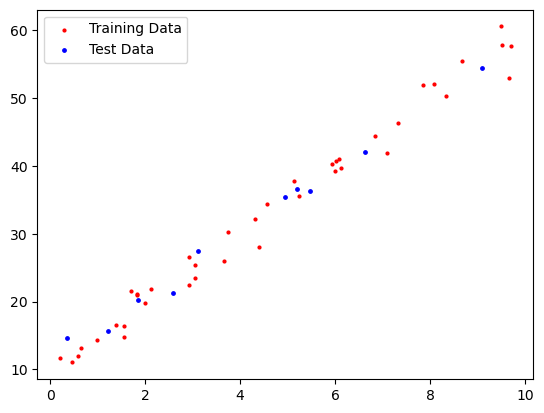

In [235]:
plt.scatter(X_train, y_train, c = "r", s = 4, label = "Training Data")
plt.scatter(X_test, y_test, c = "b", s = 6, label = "Test Data")
plt.legend()
plt.show()

In [236]:
# pytorch ann

In [237]:
from torch import nn

In [238]:
class SimpleLinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(torch.randn(1, dtype = torch.float), requires_grad= True)
        self.bias = nn.Parameter(torch.randn(1, dtype = torch.float), requires_grad= True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [239]:
torch.manual_seed(42)

model_0 = SimpleLinearRegressionModel()
model_0 = torch.compile(model_0)

In [240]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [241]:
model_0.state_dict()

OrderedDict([('_orig_mod.weights', tensor([0.3367])),
             ('_orig_mod.bias', tensor([0.1288]))])

In [242]:
with torch.inference_mode():
    y_pred = model_0(X_test)

In [243]:
len(X_test)

10

In [244]:
len(y_pred)

10

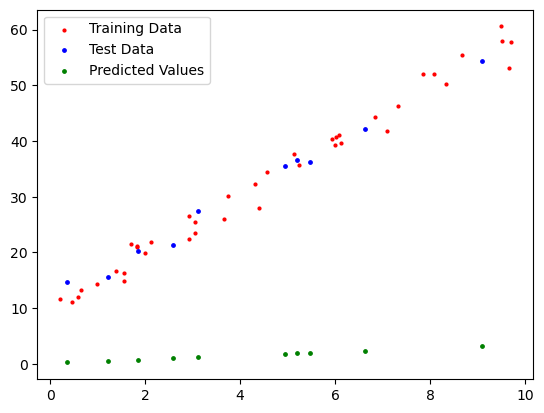

In [245]:
plt.scatter(X_train, y_train, c = "r", s = 4, label = "Training Data")
plt.scatter(X_test, y_test, c = "b", s = 6, label = "Test Data")
plt.scatter(X_test, y_pred, c = "g", s = 6, label = "Predicted Values")
plt.legend()
plt.show()

In [246]:
loss_fn = nn.MSELoss()
#loss_fn = nn.L1Loss() #MAE Loss

optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.001)

In [247]:
torch.manual_seed(42)

epochs = 120
train_loss_values = []
test_loss_values = []
epoch_count = []

In [248]:
for epoch in range(epochs):
    #train mode
    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #evaluation mode
    model_0.eval()
    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, y_test) # loss_fn(test_pred, y_test.type(torch.float))

        if (epoch % 5 == 0):
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch}, Train Loss: {loss}, Test Loss: {test_loss}")

Epoch: 0, Train Loss: 1156.0767463081781, Test Loss: 858.3088601466609
Epoch: 5, Train Loss: 633.9334744710083, Test Loss: 484.2837829868179
Epoch: 10, Train Loss: 352.99125276114285, Test Loss: 280.9052100546004
Epoch: 15, Train Loss: 201.80191856738534, Test Loss: 169.89187973557063
Epoch: 20, Train Loss: 120.41268871324436, Test Loss: 108.98031233032039
Epoch: 25, Train Loss: 76.57232180621143, Test Loss: 75.32370882849362
Epoch: 30, Train Loss: 52.9314284286948, Test Loss: 56.55033419714632
Epoch: 35, Train Loss: 40.157054153236494, Test Loss: 45.945311342231705
Epoch: 40, Train Loss: 33.2285363195233, Test Loss: 39.85291566548663
Epoch: 45, Train Loss: 29.445092396910468, Test Loss: 36.274782454905974
Epoch: 50, Train Loss: 27.353849871049174, Test Loss: 34.112658291136
Epoch: 55, Train Loss: 26.173215583708338, Test Loss: 32.758721543163134
Epoch: 60, Train Loss: 25.482771128378353, Test Loss: 31.873637954658694
Epoch: 65, Train Loss: 25.056327615659907, Test Loss: 31.26573758617

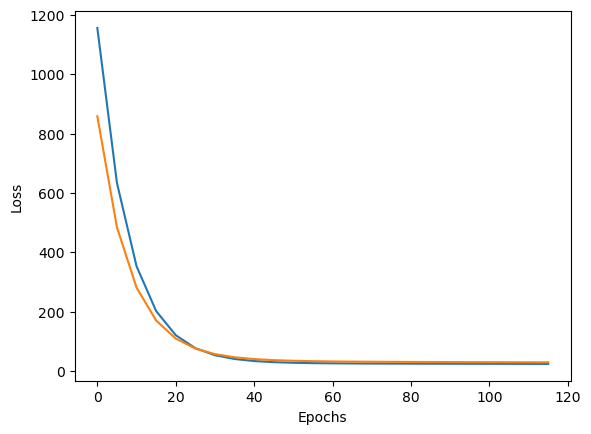

In [249]:
plt.plot(epoch_count, train_loss_values, label = "Train Loss")
plt.plot(epoch_count, test_loss_values, label = "Test Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.show()

In [250]:
model_0.state_dict()

OrderedDict([('_orig_mod.weights', tensor([6.2983])),
             ('_orig_mod.bias', tensor([1.6607]))])

In [251]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

In [252]:
X_test

tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)

In [253]:
y_preds

tensor([ 9.3471, 32.8485,  3.8266, 58.9326, 17.9595, 43.3885, 21.2933, 34.4162,
        36.0943, 13.3034], dtype=torch.float64)

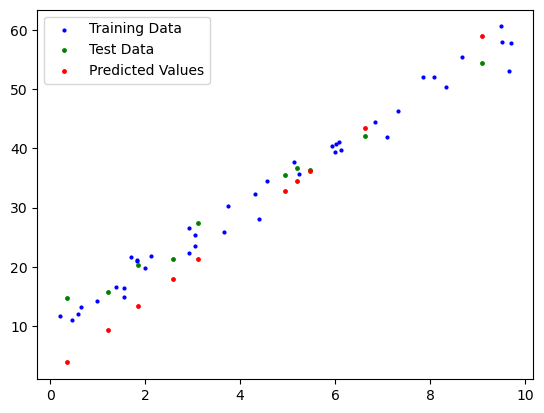

In [254]:
plt.scatter(X_train, y_train, c = "b", s = 4, label = "Training Data")
plt.scatter(X_test, y_test, c = "g", s = 6, label = "Test Data")
plt.scatter(X_test, y_preds, c = "r", s = 6, label = "Predicted Values")
plt.legend()
plt.show()